In [61]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
import joblib

In [63]:
df=pd.read_csv('/content/drive/MyDrive/ML_Projects/Customer_Default_Prediction/data/UCI_Credit_Card.csv')

In [64]:
df.shape

(30000, 25)

In [65]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

In [67]:
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [68]:
df.isnull().sum()

,0
ID,0
LIMIT_BAL,0
SEX,0
EDUCATION,0
MARRIAGE,0
AGE,0
PAY_0,0
PAY_2,0
PAY_3,0
PAY_4,0


checking target distribution

In [69]:
df['default.payment.next.month'].value_counts()#0 for no default and 1 for default

,count
default.payment.next.month,
0,23364
1,6636


In [70]:
df['default.payment.next.month'].value_counts(normalize=True)*100

,proportion
default.payment.next.month,
0,77.88
1,22.12


visualizing target


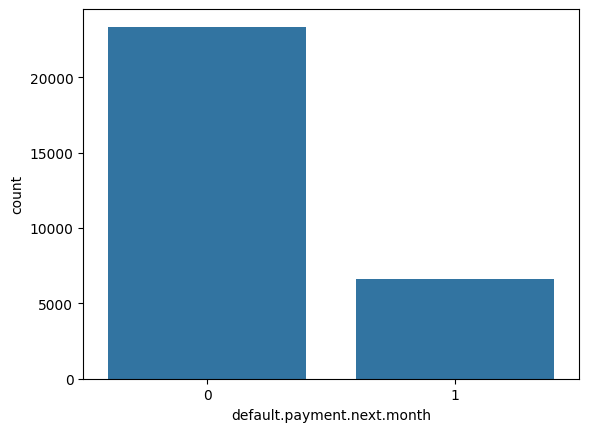

In [71]:
sns.countplot(x='default.payment.next.month',data=df)
plt.show()

drop id

In [118]:
if "Unnamed: 0" in df.columns:
    df.drop("Unnamed: 0", axis=1, inplace=True)

if "ID" in df.columns:
    df.drop("ID", axis=1, inplace=True)

cheking max and min for age and credit limit

In [73]:
df['AGE'].describe()

,AGE
count,30000.000000
mean,35.485500
std,9.217904
min,21.000000
25%,28.000000
50%,34.000000
75%,41.000000
max,79.000000


In [74]:
df['LIMIT_BAL'].describe()

,LIMIT_BAL
count,30000.000000
mean,167484.322667
std,129747.661567
min,10000.000000
25%,50000.000000
50%,140000.000000
75%,240000.000000
max,1000000.000000


checking default avg based on education , sex and marriage

In [75]:
default_rate_by_sex =df.groupby('SEX')['default.payment.next.month'].mean()

print(default_rate_by_sex)

SEX
1    0.241672
2    0.207763
Name: default.payment.next.month, dtype: float64


In [76]:
default_rate_by_education =df.groupby('EDUCATION')['default.payment.next.month'].mean()

print(default_rate_by_education)

EDUCATION
0    0.000000
1    0.192348
2    0.237349
3    0.251576
4    0.056911
5    0.064286
6    0.156863
Name: default.payment.next.month, dtype: float64


In [77]:
default_rate_by_marriage =df.groupby('MARRIAGE')['default.payment.next.month'].mean()

print(default_rate_by_marriage)

MARRIAGE
0    0.092593
1    0.234717
2    0.209283
3    0.260062
Name: default.payment.next.month, dtype: float64


correlation analysis

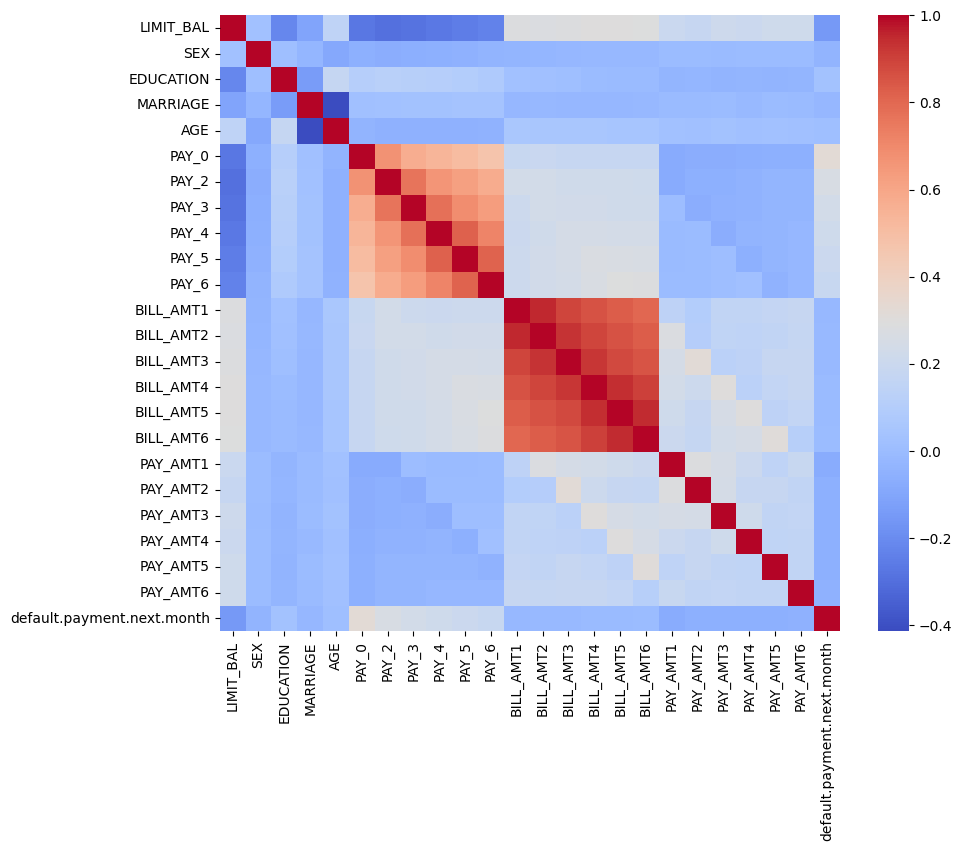

In [78]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    cmap='coolwarm'
)
plt.show()

In [79]:
corr = df.corr()

corr['default.payment.next.month'].sort_values(ascending=False)

,default.payment.next.month
default.payment.next.month,1.000000
PAY_0,0.324794
PAY_2,0.263551
PAY_3,0.235253
PAY_4,0.216614
PAY_5,0.204149
PAY_6,0.186866
EDUCATION,0.028006
AGE,0.013890
BILL_AMT6,-0.005372


In [80]:
# df.to_csv('/content/drive/MyDrive/ML_Projects/Customer_Default_Prediction/eda_completed.csv')

In [81]:
df['EDUCATION'].value_counts().sort_index()# lets consider 1,2,3,4 as school,highschool , university and others respectively

,count
EDUCATION,
0,14
1,10585
2,14030
3,4917
4,123
5,280
6,51


In [82]:
df['EDUCATION'] = df['EDUCATION'].replace([0,5,6], 4)

In [83]:
df['MARRIAGE'].value_counts().sort_index()#1 = Married, 2 = Single ,3 = Others

,count
MARRIAGE,
0,54
1,13659
2,15964
3,323


In [84]:
df['MARRIAGE'] = df['MARRIAGE'].replace(0,3)


In [85]:
df.duplicated().sum()


np.int64(35)

In [86]:
df['TOTAL_BILL'] = (
    df['BILL_AMT1']
    + df['BILL_AMT2']
    + df['BILL_AMT3']
    + df['BILL_AMT4']
    + df['BILL_AMT5']
    + df['BILL_AMT6']
)

In [87]:
df['TOTAL_PAYMENT'] = (
    df['PAY_AMT1']
    + df['PAY_AMT2']
    + df['PAY_AMT3']
    + df['PAY_AMT4']
    + df['PAY_AMT5']
    + df['PAY_AMT6']
)

In [88]:
df['PAYMENT_RATIO'] = (
    df['TOTAL_PAYMENT']
    /
    (df['TOTAL_BILL'] + 1)
)

In [89]:
X = df.drop('default.payment.next.month', axis=1)

y = df['default.payment.next.month']

In [90]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)#stratify to maintain class distribution for imbalanced dataset

In [91]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [92]:
results=[]


Logistic Regression

In [93]:
lr = LogisticRegression(
    max_iter=1000
)

lr.fit(
    X_train_scaled,
    y_train
)

LogisticRegression(max_iter=1000)

In [94]:
y_pred = lr.predict(
    X_test_scaled
)

y_prob = lr.predict_proba(
    X_test_scaled
)[:,1]

In [95]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

print("Accuracy :", accuracy)

print("Precision :", precision)

print("Recall :", recall)

print("F1 :", f1)

print("ROC-AUC :", roc_auc)

Accuracy : 0.8083333333333333
Precision : 0.6895074946466809
Recall : 0.2426525998492841
F1 : 0.358974358974359
ROC-AUC : 0.7079722196375433


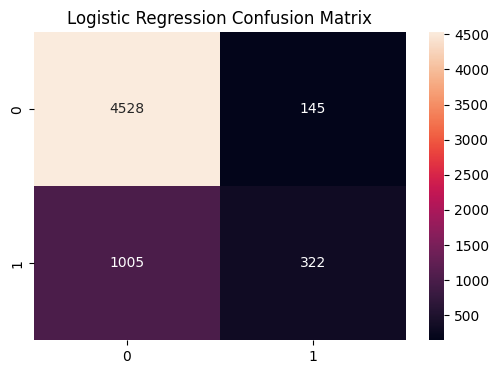

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4673
           1       0.69      0.24      0.36      1327

    accuracy                           0.81      6000
   macro avg       0.75      0.61      0.62      6000
weighted avg       0.79      0.81      0.77      6000



In [96]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.show()


print(
    classification_report(
        y_test,
        y_pred
    )
)

In [97]:
results.append({
    "Model":"Logistic Regression",
    "Accuracy":accuracy,
    "Precision":precision,
    "Recall":recall,
    "F1":f1,
    "ROC_AUC":roc_auc
})

In [98]:
print(results)

[{'Model': 'Logistic Regression', 'Accuracy': 0.8083333333333333, 'Precision': 0.6895074946466809, 'Recall': 0.2426525998492841, 'F1': 0.358974358974359, 'ROC_AUC': np.float64(0.7079722196375433)}]


2:Decision tree

In [99]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [100]:
y_pred = dt.predict(X_test)

y_prob = dt.predict_proba(X_test)[:, 1]

Accuracy : 0.7238333333333333
Precision : 0.381635581061693
Recall : 0.400904295403165
F1 : 0.3910327085630283
ROC-AUC : 0.6087011421091615


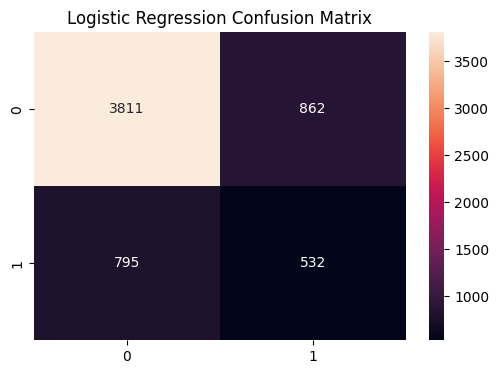

              precision    recall  f1-score   support

           0       0.83      0.82      0.82      4673
           1       0.38      0.40      0.39      1327

    accuracy                           0.72      6000
   macro avg       0.60      0.61      0.61      6000
weighted avg       0.73      0.72      0.73      6000



In [101]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

print("Accuracy :", accuracy)

print("Precision :", precision)

print("Recall :", recall)

print("F1 :", f1)

print("ROC-AUC :", roc_auc)


cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.show()


print(
    classification_report(
        y_test,
        y_pred
    )
)

In [102]:
results.append({
    "Model": "Decision Tree",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1": f1,
    "ROC_AUC": roc_auc
})

In [103]:
print(results)

[{'Model': 'Logistic Regression', 'Accuracy': 0.8083333333333333, 'Precision': 0.6895074946466809, 'Recall': 0.2426525998492841, 'F1': 0.358974358974359, 'ROC_AUC': np.float64(0.7079722196375433)}, {'Model': 'Decision Tree', 'Accuracy': 0.7238333333333333, 'Precision': 0.381635581061693, 'Recall': 0.400904295403165, 'F1': 0.3910327085630283, 'ROC_AUC': np.float64(0.6087011421091615)}]


3: Random forest

In [104]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [105]:
y_pred = rf.predict(X_test)

y_prob = rf.predict_proba(X_test)[:, 1]

Accuracy : 0.8138333333333333
Precision : 0.6392572944297082
Recall : 0.3632253202712886
F1 : 0.4632388274867852
ROC-AUC : 0.7515043772277402


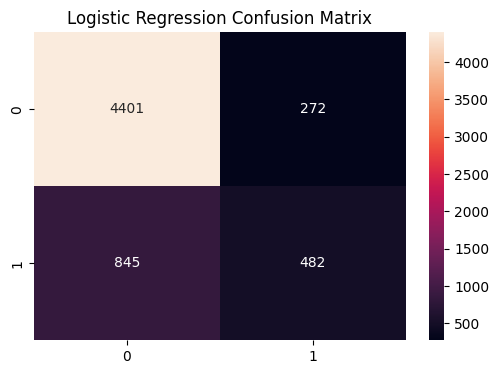

              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4673
           1       0.64      0.36      0.46      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.65      0.68      6000
weighted avg       0.79      0.81      0.79      6000



In [106]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

print("Accuracy :", accuracy)

print("Precision :", precision)

print("Recall :", recall)

print("F1 :", f1)

print("ROC-AUC :", roc_auc)


cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.show()


print(
    classification_report(
        y_test,
        y_pred
    )
)

In [107]:
results.append({
    "Model": "Random Forest",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1": f1,
    "ROC_AUC": roc_auc
})

In [108]:
print(results)

[{'Model': 'Logistic Regression', 'Accuracy': 0.8083333333333333, 'Precision': 0.6895074946466809, 'Recall': 0.2426525998492841, 'F1': 0.358974358974359, 'ROC_AUC': np.float64(0.7079722196375433)}, {'Model': 'Decision Tree', 'Accuracy': 0.7238333333333333, 'Precision': 0.381635581061693, 'Recall': 0.400904295403165, 'F1': 0.3910327085630283, 'ROC_AUC': np.float64(0.6087011421091615)}, {'Model': 'Random Forest', 'Accuracy': 0.8138333333333333, 'Precision': 0.6392572944297082, 'Recall': 0.3632253202712886, 'F1': 0.4632388274867852, 'ROC_AUC': np.float64(0.7515043772277402)}]


4:Gradient Boosting

In [109]:
gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [110]:
y_pred = gb.predict(X_test)

y_prob = gb.predict_proba(X_test)[:, 1]

Accuracy : 0.8195
Precision : 0.6648648648648648
Recall : 0.3707611152976639
F1 : 0.4760522496371553
ROC-AUC : 0.7788829542509672


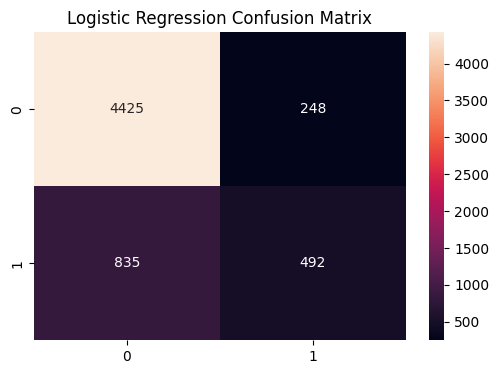

              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.66      0.37      0.48      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.66      0.68      6000
weighted avg       0.80      0.82      0.80      6000



In [111]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

print("Accuracy :", accuracy)

print("Precision :", precision)

print("Recall :", recall)

print("F1 :", f1)

print("ROC-AUC :", roc_auc)


cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.show()


print(
    classification_report(
        y_test,
        y_pred
    )
)

In [112]:
results.append({
    "Model": "Gradient Boosting",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1": f1,
    "ROC_AUC": roc_auc
})

In [113]:
print(results)

[{'Model': 'Logistic Regression', 'Accuracy': 0.8083333333333333, 'Precision': 0.6895074946466809, 'Recall': 0.2426525998492841, 'F1': 0.358974358974359, 'ROC_AUC': np.float64(0.7079722196375433)}, {'Model': 'Decision Tree', 'Accuracy': 0.7238333333333333, 'Precision': 0.381635581061693, 'Recall': 0.400904295403165, 'F1': 0.3910327085630283, 'ROC_AUC': np.float64(0.6087011421091615)}, {'Model': 'Random Forest', 'Accuracy': 0.8138333333333333, 'Precision': 0.6392572944297082, 'Recall': 0.3632253202712886, 'F1': 0.4632388274867852, 'ROC_AUC': np.float64(0.7515043772277402)}, {'Model': 'Gradient Boosting', 'Accuracy': 0.8195, 'Precision': 0.6648648648648648, 'Recall': 0.3707611152976639, 'F1': 0.4760522496371553, 'ROC_AUC': np.float64(0.7788829542509672)}]


In [114]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': gb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
5,PAY_0,0.628270
6,PAY_2,0.065146
25,PAYMENT_RATIO,0.034076
7,PAY_3,0.031758
0,LIMIT_BAL,0.025363
24,TOTAL_PAYMENT,0.024487
11,BILL_AMT1,0.023707
8,PAY_4,0.020100
23,TOTAL_BILL,0.019107
10,PAY_6,0.017851


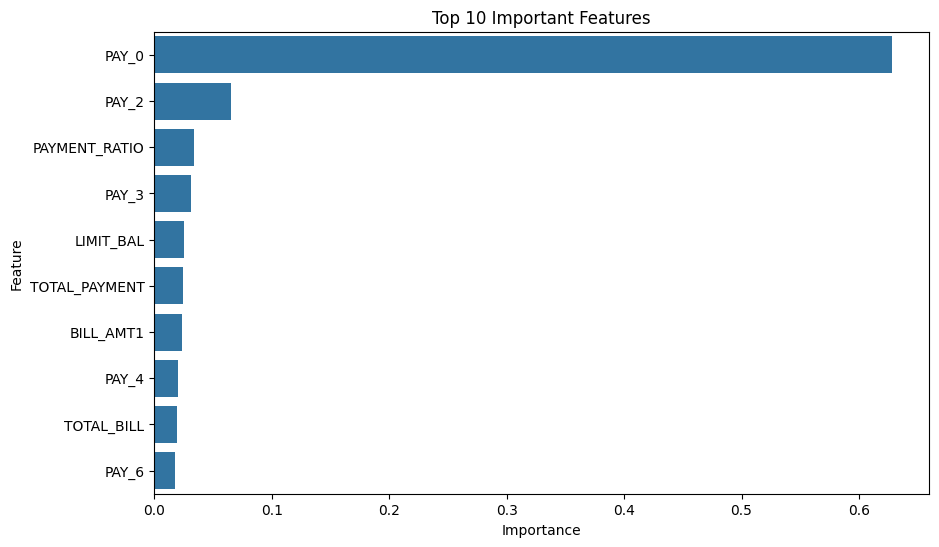

In [115]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title('Top 10 Important Features')
plt.show()

In [119]:
joblib.dump(
    gb,
    "/content/drive/MyDrive/ML_Projects/Customer_Default_Prediction/model.pkl"
)

['/content/drive/MyDrive/ML_Projects/Customer_Default_Prediction/model.pkl']

In [120]:
import joblib

model = joblib.load("/content/drive/MyDrive/ML_Projects/Customer_Default_Prediction/model.pkl")

print(model.feature_names_in_)

['LIMIT_BAL' 'SEX' 'EDUCATION' 'MARRIAGE' 'AGE' 'PAY_0' 'PAY_2' 'PAY_3'
 'PAY_4' 'PAY_5' 'PAY_6' 'BILL_AMT1' 'BILL_AMT2' 'BILL_AMT3' 'BILL_AMT4'
 'BILL_AMT5' 'BILL_AMT6' 'PAY_AMT1' 'PAY_AMT2' 'PAY_AMT3' 'PAY_AMT4'
 'PAY_AMT5' 'PAY_AMT6' 'TOTAL_BILL' 'TOTAL_PAYMENT' 'PAYMENT_RATIO']
